In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
from prettytable import PrettyTable

In [2]:
#-------------------site recorded data for particular DT---------
n_houses = 6
Current_loading = 100                                                   # % loading in existing transformer 
Current_transformer_size = 25                                              # Current size of distribution transformer

In [3]:
#---------------------define optimization parameters-----------------------
n=25  #planning horizon

#---------------------Load forecasting data------------
growth_rate = 0.012  #base load growth

# Year at which PV integration
Power_of_PV = 0   # Expected power of PV
PV_pen_year = 5  # Expected  PV integration year 

EV_projection1 = 0.5 # Consumer to EV ratio  first bump
EV_penetration_year = 5  #expected pv penetration year 

EV_projection2 =  1  #second bump
EV_penetration_year2 = 10 # years 

# Heat pump projected loads 

Power_of_HP = 4 #kw

HP_ratio2= 0.5
HP_ratio1 = 0.25

HP_bump2 = 10 
HP_bump1 = 5

In [4]:
# ---------------------- define parameters for EV----------------------
n_trials = 10000          
battery_capacity = 60      # in kWhr 60
charging_power = 7.5      # In kW 7.5
efficiency = 0.8
Lmax = 250                 # In Miles

travel_mu = 2.61     
travel_sigma = 1.32       
arrival_mu = 16           # Residential: 16,  delay: 24  , commercial: 9   # calulcated from NHTS data for residential loads     
arrival_sigma = 4          # residential: 4 ,   delay: 2.5      commercial: 3

In [5]:
# ---------- MONTE CARLO SIMULATION  ----------
def EV_calculation(Customer_to_EV_Ratio):
    n_Evs= int(n_houses * Customer_to_EV_Ratio)
    aggregate_profiles = []

    for trial in range(n_trials):
        load_profile = np.zeros(24)  

        for house in range(n_Evs):
            # Step 1: randomly select travel distance
            distance = np.random.lognormal(mean=travel_mu, sigma=travel_sigma)
            distance = min(distance, 350)

            # Step 2: Calculate initial SOC
            E0 = 0.85 - (distance / Lmax)
            E0 = np.clip(E0, 0, 0.85)

            # Step 3: Charging duration
            charging_duration = ((0.85 - E0) * battery_capacity) / (charging_power * efficiency)
            hours_needed = int(np.ceil(charging_duration))

            # Step 4: Sample arrival time
            arrival_time = int(np.clip(np.random.normal(arrival_mu, arrival_sigma), 0, 23))

            # Step 5: Schedule charging 
            hour_pointer = arrival_time
            hours_charged = 0

            while hours_charged < hours_needed:
                t = hour_pointer % 24
                load_profile[t] += charging_power
                hours_charged += 1
                hour_pointer += 1

        aggregate_profiles.append(load_profile)

    aggregate_profiles = np.array(aggregate_profiles)
    EV_load = np.percentile(aggregate_profiles, 98, axis=0)

    return EV_load


In [6]:
#---------------------Read the normalized Base load Curve and PV output---------------
base_df = pd.read_excel("Final_load_curve.xlsx", sheet_name="Seasonal_loads")
base_load = base_df['residential_load'].values  #residential_load, Large_office, Flat

base_winter = base_df['Winter'].values  
base_Spring = base_df['Spring'].values  
base_Summer= base_df['Summer'].values  
base_Fall = base_df['Fall'].values
HP = base_df['Heat_Pump'].values

pv_df = pd.read_excel("PV Output Curve Normalized Data.xlsx")
pv_profile = pv_df['Annual_Avg'].values

In [7]:
#---------------------------Net Power Calculation----------------------------

Winter_Loading = base_winter * Current_loading * Current_transformer_size/100
Spring_Loading = base_Spring * Current_loading * Current_transformer_size/100
Summer_Loading = base_Summer * Current_loading * Current_transformer_size/100
Fall_Loading   = base_Fall * Current_loading * Current_transformer_size/100

base_K_winter = np.zeros((n, 24))
base_K_spring = np.zeros((n, 24))
base_K_summer = np.zeros((n, 24))
base_K_fall   = np.zeros((n, 24))

for i in range(n):
    pv_add = n_houses* 1 *pv_profile * Power_of_PV if i >= PV_pen_year else 0

    if i >= EV_penetration_year2:
        ev_add = EV_calculation(EV_projection2)
    elif i >= EV_penetration_year:
        ev_add = EV_calculation(EV_projection1)
    else:
        ev_add = 0

    if i>= HP_bump2:
        HP_add= Power_of_HP * HP* HP_ratio2 *n_houses
    elif i>= HP_bump1:
        HP_add= Power_of_HP * HP* HP_ratio1*n_houses
    else:
        HP_add = 0
        
    base_K_winter[i] = Winter_Loading *(1 + growth_rate) ** i + ev_add - pv_add + HP_add
    base_K_spring[i] = Spring_Loading *(1 + growth_rate) ** i + ev_add - pv_add
    base_K_summer[i] = Summer_Loading*(1 + growth_rate) ** i + ev_add - pv_add
    base_K_fall[i] = Fall_Loading  *(1 + growth_rate) ** i + ev_add - pv_add

Peak_Load = np.zeros(n)
for i in range(n):
    Peak_Load[i] = Overall_Peak = np.max([
    np.max(base_K_winter[i]),
    np.max(base_K_spring[i]),
    np.max(base_K_summer[i]),
    np.max(base_K_fall[i])
])

In [8]:
# ---------------------- define parameters of IEEE Transformer Aging Model ----------------------
rated_life_hours = 180000  
delta_theta_TO_R = 60  
delta_theta_HS_R = 20  
R = 4.87  
n_exp = 0.8  
m = 0.8  
tau_TO_R = 3.5  

In [9]:
# ------------------- Transformer Thermal Model to calculate the Winding Hottest spot temperature ------------------
def thermal_model(K, ambient_temp):
    delta_theta_TO_R = 60
    delta_theta_HS_R = 20
    R = 4.87
    tau_TO = 3.5
    tau_w = 0.1 
    theta_H_list = []
    Ki = 0.634
    for i in range(len(K)):
        Ku = K[i]
        
        delta_theta_TO_i = delta_theta_TO_R * ((Ki**2 * R + 1) / (R + 1))
        delta_theta_TO_u = delta_theta_TO_R * ((Ku**2 * R + 1) / (R + 1))
        delta_theta_TO = delta_theta_TO_u * (1 - np.exp(-1 / tau_TO)) + delta_theta_TO_i * np.exp(-1 / tau_TO)
        
        delta_theta_H_u = delta_theta_HS_R * Ku**2
        delta_theta_H_i = delta_theta_HS_R * Ki**2
        delta_theta_H = delta_theta_H_u * (1 - np.exp(-1 / tau_w)) + delta_theta_H_i * np.exp(-1 / tau_w)
        
        theta_H = ambient_temp[i] + delta_theta_TO + delta_theta_H
        theta_H_list.append(theta_H)
        Ki = Ku
    return theta_H_list


In [10]:
# ---------------------- define parameters of optimizer----------------------
Transformer_sizes = [15, 25, 37.5, 50, 75, 100]
#C_invest = [35000, 38530, 40150, 101780, 152490, 260530] 

C_invest = [3500, 3853, 4015, 4178, 5249, 6053] 

C_electricity = 0.14  # $/kWh 
k_core = 0.01  
k_copper = 0.01 
r = 0.07    #discount factor 
Interruption_cost_rate = 4  
Interruption_time = [4,4,4,4,4,4]

Emergenecy_replace_cost = [1.1 * cost for cost in C_invest]
C_replace = C_invest.copy() 

In [1]:
# # ---------------------- calculate remaining transformer life ----------------------
# df=pd.read_excel('Hourly_Avg_Weather.xlsx')

# #ambient_temp = df['Minnesota'].values
# # ambient_temp = df['Texas'].values
ambient_temp= np.full(24, 30)

seasons = ['winter', 'spring', 'summer', 'fall']

base_K_by_season = {
    'winter': base_K_winter,
    'spring': base_K_spring,
    'summer': base_K_summer,
    'fall'  : base_K_fall
}

days_in_season = {
    'winter': 90,
    'spring': 92,
    'summer': 92,
    'fall'  : 91
}

def transformer_life(j, installation_year,replacement):
    cumulative_life_loss = 0.0  

    for year in range(installation_year, n):
        yearly_loss_of_life = 0.0  

        for season in seasons:
            base= np.asarray(base_K_by_season[season])
            Load_profile = base[year]

            loading_pu = (Load_profile ) / Transformer_sizes[j]
            theta_H = thermal_model(loading_pu, ambient_temp)
            
            aaf_hourly = np.exp((15000 / 383) - (15000 / (np.asarray(theta_H) + 273)))
            F_eqa = np.mean(aaf_hourly)
            
            season_days = days_in_season[season]
            seasonal_loss_of_life = (F_eqa * 24 * season_days) / rated_life_hours

            yearly_loss_of_life += seasonal_loss_of_life

        cumulative_life_loss += yearly_loss_of_life

        if replacement <= year:
            return 1-cumulative_life_loss
            break
        elif cumulative_life_loss >= 1:
            return (year) - installation_year
    
    return n - installation_year
    
def yearly_life_loss(size_idx, year):
    yearly_loss = 0.0

    for season in seasons:
        load_profile = np.asarray(base_K_by_season[season])[year]

        loading_pu = load_profile / Transformer_sizes[size_idx]
        theta_H = thermal_model(loading_pu, ambient_temp)

        aaf_hourly = np.exp((15000 / 383) - (15000 / (np.asarray(theta_H) + 273)))
        F_eqa = np.mean(aaf_hourly)

        yearly_loss += (F_eqa * days_in_season[season]) / 365

    return float(yearly_loss)   # fraction of rated life used in this year

yearly_loss = {
    (i, j): round(yearly_life_loss(i, j),2)
    for i in range(len(Transformer_sizes))
    for j in range(n)
}

residual_frac = {}
for i in range(len(Transformer_sizes)):
    residual_frac[i] = {}
    for k in range(n):
        residual_frac[i][k] = {}
        for j in range(k+1, n):   # removal year j, install year k
            lol_pct = transformer_life(i, k, j-1)          # used until year j-1
            lol_pct = min(100.0, max(0.0, float(lol_pct))) # clamp
            residual_frac[i][k][j] = max(0.0, 1.0 - lol_pct/100.0)

residual_end = {}
for i in range(len(Transformer_sizes)):
    residual_end[i] = {}
    for k in range(n):
        lol_pct_end = transformer_life(i, k, n-1)          # used until last year
        lol_pct_end = min(100.0, max(0.0, float(lol_pct_end)))
        residual_end[i][k] = max(0.0, 1.0 - lol_pct_end/100.0)

print(transformer_life(3, 0,42))

# x=np.zeros(n+1)
# x[0]=0
# for i in range(n):
#     x[i+1]= x[i] + yearly_loss[2,i]
#     print(x[i+1])

NameError: name 'np' is not defined

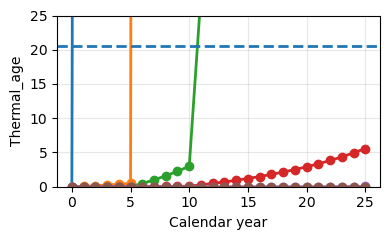

In [12]:
import numpy as np
import matplotlib.pyplot as plt

years = np.arange(n)

plt.figure(figsize=(4, 2.5))

normal_life_years = rated_life_hours / (24 * 365)

for i, size in enumerate(Transformer_sizes):
    cum_age = np.zeros(n + 1)
    for j in range(n):
        cum_age[j + 1] = cum_age[j] + yearly_loss[i, j]

    plt.plot(np.arange(n + 1), cum_age, marker='o', linewidth=2, label=f"{size} kVA")

plt.axhline(normal_life_years, linestyle='--', linewidth=2,
            label=f"Nominal life = {normal_life_years:.2f} years")

plt.xlabel("Calendar year")
plt.ylabel("Thermal_age")
plt.ylim(0,25)
plt.grid(True, alpha=0.3)
#plt.legend()
plt.tight_layout()
plt.savefig("Thermal_age.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# ---------------------- define outage probablity of the transformer ----------------------
eta= 20
beta= 4

step = 0.01
pwl_x = [i * step for i in range(int(n/ step))]
pwl_y = [1 - np.exp(- ((age / eta) ** beta) ) if age > 0 else 0 for age in pwl_x]

In [14]:
# ---------------------- Initialization with gurobi ----------------------
model = gp.Model("Transformer_Sizing")  

x = model.addVars(len(Transformer_sizes), n, vtype=GRB.BINARY, name="transformeruse")  
y = model.addVars(len(Transformer_sizes), n, vtype=GRB.BINARY, name="Install")
z = model.addVars(len(Transformer_sizes), n, vtype=GRB.BINARY, name="Salvage")
w = model.addVars(len(Transformer_sizes), n, vtype=GRB.CONTINUOUS, name="Ageoftransformer")
p = model.addVars(len(Transformer_sizes), n, vtype=GRB.CONTINUOUS, name="outage_prob")

I = range(len(Transformer_sizes))
K = range(n)

u_index = [(i,k,j) for i in I for k in K for j in range(k+1, n)]
u = model.addVars(u_index, vtype=GRB.BINARY, name="u")

keep = model.addVars([(i,k) for i in I for k in K], vtype=GRB.BINARY, name="keep")

Set parameter Username
Set parameter LicenseID to value 2754521
Academic license - for non-commercial use only - expires 2026-12-12


In [15]:
# ---------------------- Cost Functions ----------------------
Investment_cost = gp.quicksum(
    y[i, j] * C_invest[i] * (1 / (1 + r) ** j)
    for i in range(len(Transformer_sizes))
    for j in range(n)
)

#-------------------------------------------------------------
Cost_of_transformer_replace = gp.quicksum(
    z[i, j] *C_replace[i] * (1 / (1 + r) ** j)
    for i in range(len(Transformer_sizes))
    for j in range(n)
)

#--------------------------------------------------------------

sum_sq_by_year = np.zeros(n)
for j in range(n):
    sum_sq_by_year[j] = (
        np.sum(base_K_winter[j] ** 2) * days_in_season['winter'] +
        np.sum(base_K_spring[j] ** 2) * days_in_season['spring'] +
        np.sum(base_K_summer[j] ** 2) * days_in_season['summer'] +
        np.sum(base_K_fall[j]   ** 2) * days_in_season['fall']
    )

Cost_of_transformer_losses = gp.quicksum(
    x[i, j] * (
        k_core * Transformer_sizes[i] * 8760  * C_electricity +
        k_copper *  (sum_sq_by_year[j]/ Transformer_sizes[i]) * C_electricity
    ) * (1 / (1 + r) ** j)
    for i in range(len(Transformer_sizes))
    for j in range(n)
)

#---------------------------------------------------------------
Cost_of_transformer_Outage = gp.quicksum(
    p[i, j] * x[i,j]*
    ( Peak_Load[j] * Interruption_time[i] * C_electricity +
        Peak_Load[j] * Interruption_cost_rate +
        Emergenecy_replace_cost[i]
    ) * (1 / (1 + r) ** j)
    for i in range(len(Transformer_sizes))
    for j in range(n)
)

#-------------------------------------------------------------
Salvage_amount = gp.quicksum(
    C_invest[i] * residual_frac[i][k][j] * u[i,k,j] * (1 / (1 + r) ** j)
    for i in I
    for k in K
    for j in range(k+1, n)
) + gp.quicksum(
    C_invest[i] * residual_end[i][k] * keep[i,k] * (1 / (1 + r) ** (n-1))
    for i in I
    for k in K
)

#----------------------------------------------------
total_cost = Investment_cost +  Cost_of_transformer_replace + Cost_of_transformer_losses - Salvage_amount + Cost_of_transformer_Outage      

model.setObjective(total_cost, GRB.MINIMIZE)

In [16]:
# ================================================================
# CONSTRAINT 1: Load Satisfaction
# Transformer capacity must meet load each period
# ================================================================
# for j in range(n):
#     model.addConstr(
#         gp.quicksum(x[i, j] * 1.5 * Transformer_sizes[i] for i in range(len(Transformer_sizes))) >= Peak_Load[j],
#         name=f"load_satisfaction_{j}"
#     )

# ================================================================
# CONSTRAINT 2: Minimum One Transformer
# At least one transformer must be active each period
# ================================================================
for j in range(n):
    model.addConstr(
        gp.quicksum(x[i, j] for i in range(len(Transformer_sizes))) >= 1,
        name=f"min_one_transformer_{j}"
    )

# ================================================================
# CONSTRAINT 3: Transformer Lifetime
# Cannot use transformer beyond its useful life
# ================================================================
# for i in range(len(Transformer_sizes)):
#     for j in range(n):
#         life = transformer_life(i, j,n+2)
#         for t in range(j + life, n):
#             model.addConstr(
#                 x[i, t] <= 1 - y[i, j],
#                 name=f"lifetime_{i}_{j}_{t}"
#             )
            
# ================================================================
# CONSTRAINT 4: Installation Logic
# y[i,j] = 1 only when transformer transitions from unused to used
# ================================================================
for i in range(len(Transformer_sizes)):
    model.addConstr(y[i, 0] == x[i, 0],                    name=f"install_init_{i}")

    for j in range(1, n):
        model.addConstr(y[i, j] >= x[i, j] - x[i, j-1],   name=f"install_lb_{i}_{j}")
        model.addConstr(y[i, j] <= x[i, j],                name=f"install_ub1_{i}_{j}")
        model.addConstr(y[i, j] <= 1 - x[i, j-1],         name=f"install_ub2_{i}_{j}")

# ================================================================
# CONSTRAINT 5: Salvage/Removal Logic
# z[i,j] = 1 only when transformer transitions from used to unused
# ================================================================
for i in range(len(Transformer_sizes)):
    model.addConstr(z[i, 0] == 0,                    name=f"salvage_init_{i}")

    for j in range(1, n):
        model.addConstr(z[i, j] >= x[i, j-1] - x[i, j],   name=f"salvage_lb_{i}_{j}")
        model.addConstr(z[i, j] <= x[i, j-1],              name=f"salvage_ub1_{i}_{j}")
        model.addConstr(z[i, j] <= 1 - x[i, j],            name=f"salvage_ub2_{i}_{j}")
        
# ================================================================
# CONSTRAINT 6: Age Tracking
# w[i,j] = number of years transformer i has been in use by period j
# ================================================================
# for i in range(len(Transformer_sizes)):
#     for j in range(1, n):
#         model.addConstr(
#             w[i, j] == x[i, j] * (w[i, j-1] + yearly_loss[i,j]),
#             name=f"age_increment_{i}_{j}"
#         )
#yearly_loss[i,j]

for i in range(len(Transformer_sizes)):
    model.addConstr(
        w[i, 0] == yearly_loss[i, 0] * x[i, 0],
        name=f"life_init_{i}"
    )

    for j in range(1, n):
        model.addConstr(
            w[i, j] == x[i, j] * (w[i, j-1] + yearly_loss[i, j]),
            name=f"age_increment_{i}_{j}"
        )
        
# ================================================================
# CONSTRAINT 7: Failure Probability (PWL)
# p[i,j] = failure probability based on transformer age w[i,j]
# ================================================================
for i in range(len(Transformer_sizes)):
    for j in range(n):
        model.addGenConstrPWL(
            w[i, j], p[i, j],
            pwl_x, pwl_y,
            name=f"failure_prob_{i}_{j}"
        ) 
    
#----------------
for i in I:
    for k in K:
        model.addConstr(
            gp.quicksum(u[i,k,j] for j in range(k+1, n)) + keep[i,k] == y[i,k],
            name=f"link_install_{i}_{k}"
        )
for i in I:
    for j in range(n):
        model.addConstr(
            gp.quicksum(u[i,k,j] for k in range(0, j)) == z[i,j],
            name=f"link_remove_{i}_{j}"
        )

In [17]:
# ---------------------- Solve the model ----------------------
model.optimize()

# ---------------------- Print the result ----------------------
status = model.status
if status == GRB.OPTIMAL:
    print("Optimal solution found!")
else:
    print("Model is infeasible.")

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 1207 rows, 2700 columns and 6242 nonzeros (Min)
Model fingerprint: 0xb6ca159a
Model has 2400 linear objective coefficients
Model has 150 quadratic objective terms
Model has 144 quadratic constraints
Model has 150 simple general constraints
  150 PWL
Variable types: 300 continuous, 2400 integer (2400 binary)
Coefficient statistics:
  Matrix range     [7e-02, 6e+02]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e-02, 9e+10]
  Objective range  [2e+02, 6e+03]
  QObjective range [2e+03, 1e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
  PWLCon x range   [1e-02, 2e+01]
  PWLCon y range   [6e-14, 9e-01]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve added 308 rows and 232309 columns
Pre

In [18]:
# ---------------------- plot the Gurobi Variables in Table ----------------------
def print_variable_table(var, var_name, binary=True, threshold=0.01):
    print(f"\n📋 {var_name.upper()} Table:")
    table = PrettyTable()
    table.field_names = ["Year"] + [f"{Transformer_sizes[i]} kVA" for i in range(len(Transformer_sizes))]

    for j in range(n):
        row = [f"Year {j}"]
        for i in range(len(Transformer_sizes)):
            val = var[i, j].X
            if binary:
                row.append("✓" if val > 0.5 else "")
            else:
                row.append(f"{val:.2f}" if val > threshold else "")
        table.add_row(row)
    print(table)

if model.status == GRB.OPTIMAL:
    print_variable_table(x, "x (transformer use)", binary=True)
    print_variable_table(y, "y (installation)", binary=True)
    print_variable_table(z, "z (removal)", binary=True)
    print_variable_table(w, "w (effective age)", binary=False)
    print_variable_table(p, "p (outage probability)", binary=False)
else:
    print("Model is not optimal, skipping variable table print.")


📋 X (TRANSFORMER USE) Table:
+---------+--------+--------+----------+--------+--------+---------+
|   Year  | 15 kVA | 25 kVA | 37.5 kVA | 50 kVA | 75 kVA | 100 kVA |
+---------+--------+--------+----------+--------+--------+---------+
|  Year 0 |        |        |          |   ✓    |        |         |
|  Year 1 |        |        |          |   ✓    |        |         |
|  Year 2 |        |        |          |   ✓    |        |         |
|  Year 3 |        |        |          |   ✓    |        |         |
|  Year 4 |        |        |          |   ✓    |        |         |
|  Year 5 |        |        |          |   ✓    |        |         |
|  Year 6 |        |        |          |   ✓    |        |         |
|  Year 7 |        |        |          |   ✓    |        |         |
|  Year 8 |        |        |          |   ✓    |        |         |
|  Year 9 |        |        |          |   ✓    |        |         |
| Year 10 |        |        |          |   ✓    |        |         |
| Ye

In [19]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ── IEEE Style ────────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family'      : 'Times New Roman',
    'font.size'        : 14,
    'axes.labelsize'   : 14,
    'xtick.labelsize'  : 12,
    'ytick.labelsize'  : 12,
    'lines.linewidth'  : 1.0,
    'figure.dpi'       : 300,
    'savefig.dpi'      : 300,
})

# ----------- SETTINGS -----------
first_bump_idx  = 5
second_bump_idx = 10
n_years = np.asarray(base_K_by_season['winter']).shape[0]
years_to_plot = [
    0,
    min(first_bump_idx,  n_years - 1),
    min(second_bump_idx, n_years - 1),
    n_years - 1
]
seas = ['winter', 'spring', 'summer', 'fall']
season_line_styles = {'winter': '-', 'spring': '--', 'summer': '-.', 'fall': ':'}
# --------------------------------

# --- Global Y range across ALL years and ALL seasons ---
global_min = np.inf
global_max = -np.inf
for year_idx in years_to_plot:
    for season in seas:
        profile = np.asarray(base_K_by_season[season])[year_idx]
        global_min = min(global_min, profile.min())
        global_max = max(global_max, profile.max())

pad   = (global_max - global_min) * 0.05
y_min = global_min - pad
y_max = global_max + pad

# --- Plot each year ---
year_labels = {
    years_to_plot[0]: 'Year 1',
    years_to_plot[1]: f'Year {first_bump_idx}',
    years_to_plot[2]: f'Year {second_bump_idx}',
    years_to_plot[3]: f'Year {n_years}',
}

for year_idx in years_to_plot:
    # IEEE single-column subfigure size
    fig, ax = plt.subplots(figsize=(1.7, 1.5))

    for season in seas:
        profile = np.asarray(base_K_by_season[season])[year_idx]
        ax.plot(profile,
                linestyle=season_line_styles[season],
                linewidth=1.0,
                label=season.capitalize())

 #   ax.set_xlabel('Hour of Day')
 #   ax.set_ylabel('Power (kW)')
    ax.set_xlim(0, len(profile) - 1)
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.3, linestyle='--', linewidth=0.4)

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    plt.savefig(f'case_5_profile_year_{year_idx}.pdf',
                format='pdf',
                bbox_inches='tight')
    plt.close()

print("PDF files saved successfully.")

PDF files saved successfully.


In [20]:
if model.status == GRB.OPTIMAL:
    
    # ── Get each component value directly from Gurobi expressions ──
    inv_cost    = Investment_cost.getValue()
    rep_cost    = Cost_of_transformer_replace.getValue()
    loss_cost   = Cost_of_transformer_losses.getValue()
    outage_cost = Cost_of_transformer_Outage.getValue()
    salvage     = Salvage_amount.getValue()
    total       = total_cost.getValue()

    # ── Print breakdown ──
    gross       = inv_cost + rep_cost + loss_cost #+ outage_cost

    print("\n" + "="*55)
    print(f"{'TRANSFORMER COST BREAKDOWN':^55}")
    print("="*55)
    print(f"{'Cost Component':<30} {'Amount ($)':>15} {'Share (%)':>8}")
    print("-"*55)
    print(f"{'Investment Cost':<30} ${inv_cost:>13,.2f} {inv_cost/gross*100:>7.1f}%")
    print(f"{'Replacement Cost':<30} ${rep_cost:>13,.2f} {rep_cost/gross*100:>7.1f}%")
    print(f"{'Energy Loss Cost':<30} ${loss_cost:>13,.2f} {loss_cost/gross*100:>7.1f}%")
    print(f"{'Outage Cost':<30} ${outage_cost:>13,.2f} {outage_cost/gross*100:>7.1f}%")
    print(f"{'Salvage Value':<30} -${salvage:>12,.2f} -{salvage/gross*100:>6.1f}%")
    print("-"*55)
    print(f"{'TOTAL COST':<30} ${total:>13,.2f}")
    print("="*55)
    print(f"\n  Gurobi Objective Value : ${model.ObjVal:,.2f}")
    print(f"  Difference             : ${abs(model.ObjVal - total):,.2f}")
    print("="*55)


              TRANSFORMER COST BREAKDOWN               
Cost Component                      Amount ($) Share (%)
-------------------------------------------------------
Investment Cost                $     4,178.00    29.2%
Replacement Cost               $         0.00     0.0%
Energy Loss Cost               $    10,125.65    70.8%
Outage Cost                    $        15.99     0.1%
Salvage Value                  -$      817.69 -   5.7%
-------------------------------------------------------
TOTAL COST                     $    13,501.95

  Gurobi Objective Value : $13,501.95
  Difference             : $0.00


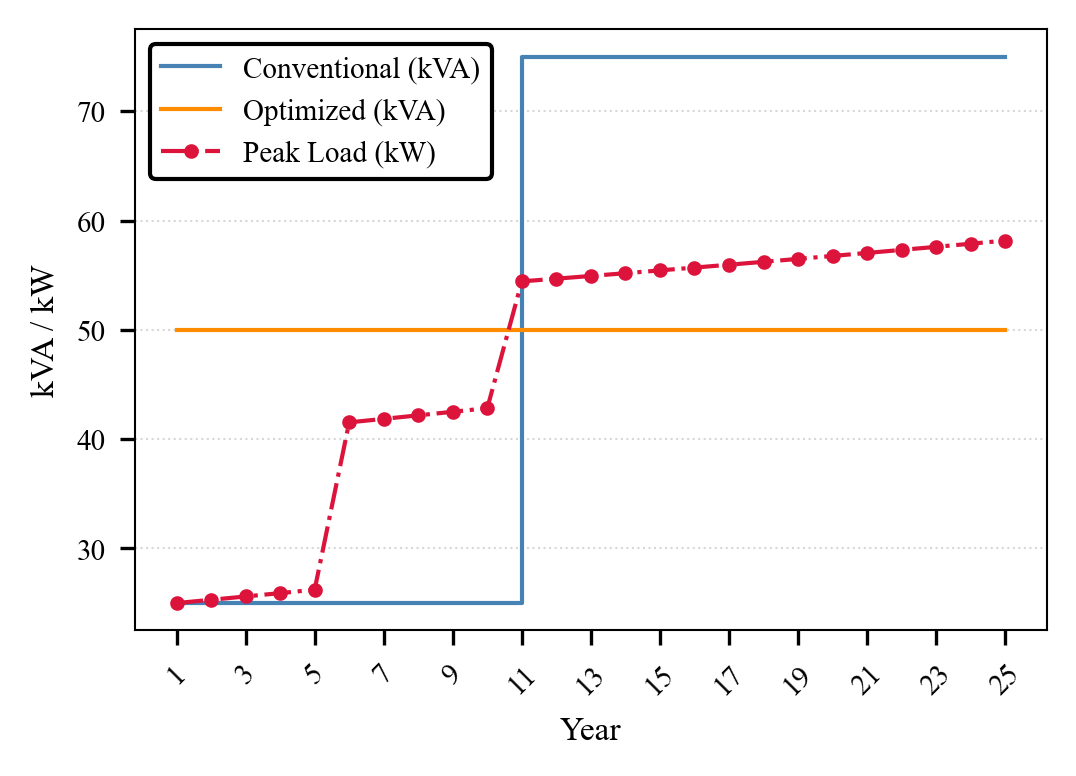

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ── IEEE Style Settings ───────────────────────────────────────────────────────

matplotlib.rcParams.update({
    'font.family'      : 'Times New Roman',
    'font.size'        : 8,
    'axes.labelsize'   : 8,
    'axes.titlesize'   : 8,
    'xtick.labelsize'  : 7,
    'ytick.labelsize'  : 7,
    'legend.fontsize'  : 7,
    'lines.linewidth'  : 1.0,
    'lines.markersize' : 3,
    'figure.dpi'       : 300,
    'savefig.dpi'      : 300,
    'savefig.format'   : 'pdf',        # IEEE prefers vector (pdf/eps)
})

# ── Manual Entry ──────────────────────────────────────────────────────────────

n = 25

# Peak_Load = np.array([...])   # already defined

conv_segments = [
    (25,  10),
    (75,  25),
]

opt_segments = [
    (50,  25)
]

# ── Build arrays from segments ────────────────────────────────────────────────

def build_from_segments(segments, n):
    active   = np.zeros(n)
    prev_end = 0
    for size, until in segments:
        start = prev_end
        end   = min(until, n)
        active[start:end] = size
        prev_end = end
    return active

conv_active = build_from_segments(conv_segments, n)
opt_active  = build_from_segments(opt_segments,  n)

# ── Plot ──────────────────────────────────────────────────────────────────────

years = np.arange(1, n + 1)

# IEEE single-column: 3.5 in wide  |  double-column: 7.16 in wide
fig, ax = plt.subplots(figsize=(3.5, 2.5))        # single column
# fig, ax = plt.subplots(figsize=(7.16, 3.0))     # double column — uncomment if needed

ax.step(years, conv_active, where='post', color='steelblue',
        linewidth=1.0, label='Conventional (kVA)')
ax.step(years, opt_active,  where='post', color='darkorange',
        linewidth=1.0, label='Optimized (kVA)')
ax.plot(years, Peak_Load[:n], color='crimson', linewidth=1.0,
        linestyle='-.', marker='o', markersize=2.5, label='Peak Load (kW)')

ax.set_xlabel('Year')
ax.set_ylabel('kVA / kW')
ax.set_xticks(years[::2])                          # every 2 years to avoid crowding
ax.set_xticklabels(years[::2], rotation=45)
ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.5)
ax.legend(loc='upper left', frameon=True, edgecolor='black', framealpha=1.0)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout(pad=0.5)

plt.savefig('transformer_schedule.pdf', bbox_inches='tight')
plt.show()

In [22]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ── IEEE Style ────────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family'   : 'Times New Roman',
    'font.size'     : 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'lines.linewidth': 1.0,
    'figure.dpi'    : 300,
    'savefig.dpi'   : 300,
})

HP         = base_df['Heat_Pump'].values
pv_profile = pv_df['Annual_Avg'].values

# ── Normalize 0 to 1 ──────────────────────────────────────────────────────────
HP_norm = HP / HP.max()
pv_norm = pv_profile / pv_profile.max()

hours = np.arange(len(HP_norm))

# ── Heat Pump ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(1.7, 1.5))
ax.plot(hours, HP_norm, color='steelblue', linewidth=1.0)
ax.set_ylabel('Normalized Power (p.u.)')
ax.set_xlabel('Hour of Day')
ax.set_xlim(0, len(HP_norm) - 1)
ax.set_ylim(0, 1.05)
ax.set_xticks([0, 6, 12, 18, 24])
ax.grid(alpha=0.3, linestyle='--', linewidth=0.4)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
plt.tight_layout(pad=0.3)
plt.savefig('hp_profile.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.close()

# ── PV ────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(1.7, 1.5))
ax.plot(hours, pv_norm, color='darkorange', linewidth=1.0)
ax.set_ylabel('Normalized Power (p.u.)')
ax.set_xlabel('Hour of Day')
ax.set_xlim(0, len(pv_norm) - 1)
ax.set_ylim(0, 1.05)
ax.set_xticks([0, 6, 12, 18, 24])
ax.grid(alpha=0.3, linestyle='--', linewidth=0.4)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
plt.tight_layout(pad=0.3)
plt.savefig('pv_profile.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.close()

print("Saved hp_profile.pdf and pv_profile.pdf")

Saved hp_profile.pdf and pv_profile.pdf
